# 1. Problem Definition

The objective is to predict the **SalePrice** of houses using selected numerical and categorical features from the House Prices dataset.

This is a **regression problem** because the target variable, `SalePrice`, is a continuous numerical value rather than a class/category. Therefore, the model is evaluated using regression metrics such as **MAE, MSE, RMSE, and R²** instead of classification accuracy.


# MACHINE LEARNING — LAB 5
## Linear Regression — Predicting House Prices

### Student Information
- **Name:** Shiza Shaikh
- **Student ID:** 0525
- **Section:** C
- **GitHub:** shizashaikh55
- **Kaggle:** shizayshaikh
- **Dataset:** House Prices — Advanced Regression Techniques
- **Dataset Source:** Kaggle

### JupyterLab Instructions
Place these three files in the **same folder** as this notebook:
- `train.csv`
- `test.csv`
- `sample_submission.csv`

Then run the notebook cells from top to bottom.

> This notebook is prepared specifically for **JupyterLab/Jupyter Notebook**, not Google Colab.


In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## Upload the Kaggle files

Upload these three files to the Colab session:
- `train.csv`
- `test.csv`
- `sample_submission.csv`

The code below checks that the files exist before continuing.


In [3]:
# JupyterLab file check
# Keep train.csv, test.csv, and sample_submission.csv in the same folder as this notebook.

from pathlib import Path

required_files = ["train.csv", "test.csv", "sample_submission.csv"]

print("Current working directory:", Path.cwd())

missing = [f for f in required_files if not Path(f).exists()]

if missing:
    print("\nMissing files:", missing)
    print("\nPlease place these files in the same folder as this Jupyter notebook:")
    for f in required_files:
        print(" -", f)
else:
    print("\nAll required files are available. ✓")


Current working directory: /drive

All required files are available. ✓


In [4]:
# Load datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)


Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


# 2. Dataset Exploration

The training dataset contains the target `SalePrice`. The Kaggle House Prices dataset has mixed data types, including numerical variables and categorical variables. The test dataset does not contain `SalePrice`.

We first inspect the shape, data types, first rows, and numerical summary statistics.


In [5]:
# First 5 rows
train_df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Interpretation:** The first rows show that each row represents a house and that the dataset contains both numerical and categorical information about the property.

In [6]:
# Dataset information
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**Interpretation:** The dataset contains a mixture of numeric and object/categorical columns, so categorical variables must be encoded before Linear Regression can use them.

In [7]:
# Summary statistics for numerical columns
train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,"1,460.0000",730.5000,421.6100,1.0000,365.7500,730.5000,"1,095.2500","1,460.0000"
MSSubClass,"1,460.0000",56.8973,42.3006,20.0000,20.0000,50.0000,70.0000,190.0000
LotFrontage,"1,201.0000",70.0500,24.2848,21.0000,59.0000,69.0000,80.0000,313.0000
LotArea,"1,460.0000","10,516.8281","9,981.2649","1,300.0000","7,553.5000","9,478.5000","11,601.5000","215,245.0000"
OverallQual,"1,460.0000",6.0993,1.3830,1.0000,5.0000,6.0000,7.0000,10.0000
OverallCond,"1,460.0000",5.5753,1.1128,1.0000,5.0000,5.0000,6.0000,9.0000
YearBuilt,"1,460.0000","1,971.2678",30.2029,"1,872.0000","1,954.0000","1,973.0000","2,000.0000","2,010.0000"
YearRemodAdd,"1,460.0000","1,984.8658",20.6454,"1,950.0000","1,967.0000","1,994.0000","2,004.0000","2,010.0000"
MasVnrArea,"1,452.0000",103.6853,181.0662,0.0000,0.0000,0.0000,166.0000,"1,600.0000"
BsmtFinSF1,"1,460.0000",443.6397,456.0981,0.0000,0.0000,383.5000,712.2500,"5,644.0000"


**Interpretation:** The summary statistics show the distributions and ranges of the numerical variables. `SalePrice` is the continuous value that we want to predict.

In [8]:
# Missing-value overview
missing_summary = train_df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

**Interpretation:** Several columns contain missing values. The preprocessing pipeline below handles missing numerical values with the median and missing categorical values with the most frequent category.

# 3. Feature and Target Identification

### Dependent Variable
- **Target (`y`):** `SalePrice`

### Independent Variables
For this lab, a manageable subset of approximately 10–12 features is selected, as recommended by the lab manual. The subset deliberately mixes numerical and categorical variables.

### Selected numerical features
1. `OverallQual`
2. `GrLivArea`
3. `TotalBsmtSF`
4. `GarageCars`
5. `YearBuilt`
6. `FullBath`
7. `1stFlrSF`

### Selected categorical features
1. `Neighborhood`
2. `HouseStyle`
3. `KitchenQual`
4. `GarageType`

These features represent overall quality, living area, basement area, garage capacity, age/year, bathrooms, floor area, neighborhood, house style, kitchen quality, and garage type.


In [10]:
# Define the selected features
numeric_features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF"
]

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageType"
]

selected_features = numeric_features + categorical_features

# Verify all selected columns exist
missing_selected = [c for c in selected_features + ["SalePrice"] if c not in train_df.columns]
if missing_selected:
    raise ValueError(f"These required columns are missing: {missing_selected}")

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total selected features:", len(selected_features))


Numerical features: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', '1stFlrSF']
Categorical features: ['Neighborhood', 'HouseStyle', 'KitchenQual', 'GarageType']
Total selected features: 11


**Interpretation:** Numerical features are used directly after missing-value treatment. Categorical features are one-hot encoded because their categories do not have a natural numerical order. One-hot encoding creates separate 0/1 columns without incorrectly implying that one category is mathematically larger than another.


# 4. Data Preparation

`LinearRegression` requires numeric input with no missing values.

### Encoding and missing-value strategy
- **Numerical columns:** missing values are replaced using the median. Median is robust to extreme house-price-related values.
- **Categorical columns:** missing values are replaced using the most frequent category, then **One-Hot Encoding** converts categories into numeric 0/1 columns.
- `handle_unknown='ignore'` allows the same preprocessing to safely transform Kaggle's unlabeled test data even if it contains a category not seen during training.


In [11]:
# Prepare X and y
X = train_df[selected_features].copy()
y = train_df["SalePrice"].copy()

print("X shape before preprocessing:", X.shape)
print("y shape:", y.shape)
print("\nMissing values in selected features:")
print(X.isnull().sum()[X.isnull().sum() > 0])


X shape before preprocessing: (1460, 11)
y shape: (1460,)

Missing values in selected features:
GarageType    81
dtype: int64


In [13]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# 5. Train/Test Split

The labeled training data is split into **80% training** and **20% testing** data. The test portion here is a held-out evaluation set from `train.csv`, so actual prices are available for calculating MAE, MSE, RMSE, and R².


In [14]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (1168, 11)
X_test shape : (292, 11)
y_train shape: (1168,)
y_test shape : (292,)


**Interpretation:** The 80/20 split leaves most houses for model training while keeping a separate set of unseen houses for an unbiased evaluation of generalization.

# 6. Linear Regression Model

A **Multiple Linear Regression** model is trained using all prepared features. A pipeline is used so that the exact same preprocessing is applied consistently to the training and held-out test data.


In [15]:
# Build and train the Linear Regression pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


# 7. Predictions

The model now generates predicted house prices for the held-out test set. The first 10 rows are displayed with their actual and predicted prices.


In [16]:
# Generate predictions
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
}).reset_index(drop=True)

comparison.head(10)


,Actual Price,Predicted Price
0,154500,"140,533.7936"
1,325000,"320,691.7843"
2,115000,"113,576.4561"
3,159000,"174,772.7993"
4,315500,"318,912.9935"
5,75500,"67,073.9818"
6,311500,"242,708.6262"
7,146000,"146,236.6949"
8,84500,"66,779.4144"
9,135500,"122,572.5402"


**Interpretation:** The comparison table shows how close the model's predicted prices are to the actual SalePrice values for unseen houses. Some differences are expected because a simple Linear Regression model cannot capture every factor affecting house prices.

# 8. Coefficients and Intercept

The fitted Linear Regression model has one coefficient for every transformed feature. Because categorical variables are one-hot encoded, their individual category columns also receive coefficients.

For a numerical feature, the coefficient represents the expected change in predicted price for a one-unit increase in that feature, while holding other model features constant. For one-hot encoded categories, the coefficient represents the change relative to the omitted/reference category.


In [17]:
# Extract transformed feature names and coefficients
fitted_preprocessor = model.named_steps["preprocessor"]
regressor = model.named_steps["regressor"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = regressor.coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add plain-English interpretation
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "")

coef_table["Feature"] = coef_table["Feature"].map(clean_feature_name)

def make_interpretation(row):
    feature = row["Feature"]
    coef = row["Coefficient"]
    if coef >= 0:
        return f"An increase/change in {feature} is associated with an approximate +{coef:,.2f} change in predicted price, holding other model features constant."
    else:
        return f"An increase/change in {feature} is associated with an approximate {coef:,.2f} change in predicted price, holding other model features constant."

coef_table["Interpretation"] = coef_table.apply(make_interpretation, axis=1)

print("Intercept:", regressor.intercept_)
coef_table


Intercept: -303436.08177128993


,Feature,Coefficient,Interpretation
0,OverallQual,"11,975.2011",An increase/change in OverallQual is associate...
1,GrLivArea,70.8181,An increase/change in GrLivArea is associated ...
2,TotalBsmtSF,11.9962,An increase/change in TotalBsmtSF is associate...
3,GarageCars,"14,623.3320",An increase/change in GarageCars is associated...
4,YearBuilt,147.2837,An increase/change in YearBuilt is associated ...
5,FullBath,-306.3075,An increase/change in FullBath is associated w...
6,1stFlrSF,-26.4066,An increase/change in 1stFlrSF is associated w...
7,Neighborhood_Blmngtn,"-26,287.1354",An increase/change in Neighborhood_Blmngtn is ...
8,Neighborhood_Blueste,"-28,189.0033",An increase/change in Neighborhood_Blueste is ...
9,Neighborhood_BrDale,"-18,453.2724",An increase/change in Neighborhood_BrDale is a...


**Interpretation:** The coefficient table exposes the direction and estimated size of each model coefficient. For one-hot categorical variables, the coefficient should be interpreted relative to the category that is represented by the model's reference/omitted encoding, not as an absolute standalone effect.


## Intercept Interpretation

The intercept is the predicted house price when every transformed feature has a value of zero. This does **not** have a strong real-world interpretation here because a house with zero living area, zero quality, zero year-built value, and zero category indicators is not a realistic property. Therefore, the intercept mainly serves as a mathematical baseline for the regression equation.


# 9. Residual Analysis

A residual is:

**Residual = Actual Price − Predicted Price**

Residual plots help identify patterns that a single metric cannot show.


In [18]:
# Calculate residuals
residuals = y_test.values - y_pred

residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_df.head()


,Actual,Predicted,Residual
0,154500,"140,533.7936","13,966.2064"
1,325000,"320,691.7843","4,308.2157"
2,115000,"113,576.4561","1,423.5439"
3,159000,"174,772.7993","-15,772.7993"
4,315500,"318,912.9935","-3,412.9935"


**Interpretation:** A positive residual means the model underestimated the house price, while a negative residual means it overestimated the house price.

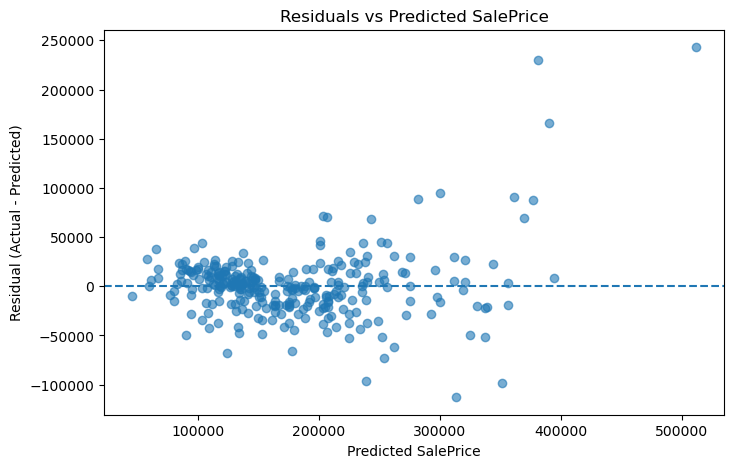

In [19]:
# Residuals vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted SalePrice")
plt.show()


**Interpretation:** Ideally, residuals should be randomly scattered around zero with no strong systematic pattern. If a clear curve or funnel shape appears, it can indicate non-linearity or non-constant error variance. The actual plot should be inspected after running the notebook.


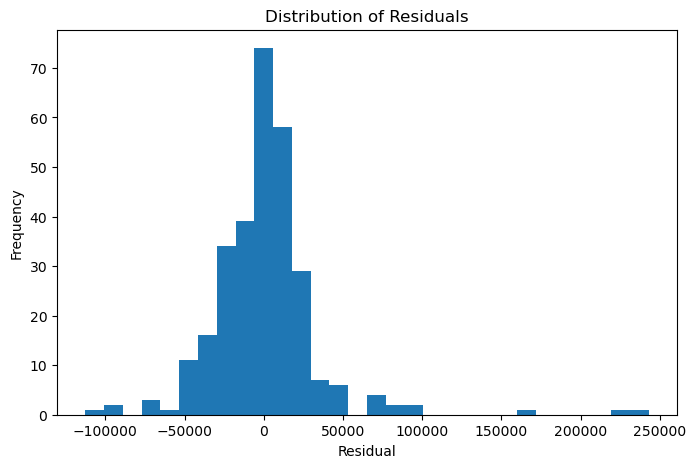

In [20]:
# Residual histogram
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()


**Interpretation:** The histogram shows how the prediction errors are distributed. A roughly centered distribution around zero indicates that the model's errors are balanced overall, although perfect normality is not required for this lab.

# 10. Regression Metrics

The required regression metrics are:

- **MAE:** average absolute prediction error; easy to understand in price units.
- **MSE:** average squared error; gives greater weight to large errors.
- **RMSE:** square root of MSE; returns to the original price units and strongly reflects large errors.
- **R²:** proportion of variation in SalePrice explained by the model; higher is generally better.


In [21]:
# Test-set metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Test Value": [test_mae, test_mse, test_rmse, test_r2]
})

test_metrics


,Metric,Test Value
0,MAE,"21,475.6910"
1,MSE,"1,226,165,134.1977"
2,RMSE,"35,016.6408"
3,R²,0.8401


**Interpretation:** MAE and RMSE are expressed in dollars, so they directly communicate prediction error in the target's units. MSE is in squared dollars and is less intuitive for a stakeholder. R² summarizes how much variation in house prices is explained by the model. For a non-technical stakeholder, **MAE** is usually the easiest metric to explain because it answers, approximately, "How many dollars off is the prediction on average?"


# 11. Training vs Testing Performance

To assess generalization, we calculate all four metrics on both the training data and the unseen held-out test data.


In [22]:
# Training predictions
train_pred = model.predict(X_train)

# Training metrics
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

comparison_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [test_mae, test_mse, test_rmse, test_r2]
})

comparison_metrics


,Metric,Training,Testing
0,MAE,"20,459.8123","21,475.6910"
1,MSE,"1,032,134,145.9170","1,226,165,134.1977"
2,RMSE,"32,126.8446","35,016.6408"
3,R²,0.8270,0.8401


**Interpretation:** Training performance is expected to be better than testing performance because the model learned from the training data. A very large gap between the two would suggest overfitting. A relatively small gap indicates better generalization to unseen houses.


In [23]:
# Quantify train-test gaps
r2_gap = train_r2 - test_r2
rmse_gap = test_rmse - train_rmse

print(f"R² train-test gap: {r2_gap:.4f}")
print(f"RMSE test-train gap: {rmse_gap:,.2f}")

if abs(r2_gap) < 0.10:
    print("Conclusion: The R² gap is relatively small, suggesting reasonable generalization.")
else:
    print("Conclusion: The R² gap is noticeable, suggesting possible overfitting or differences between train and test performance.")


R² train-test gap: -0.0132
RMSE test-train gap: 2,889.80
Conclusion: The R² gap is relatively small, suggesting reasonable generalization.


# 12. Model Interpretation

## Most influential features

A raw coefficient magnitude must be interpreted carefully because the features are on different scales. For example, `GrLivArea` is measured in square feet while `OverallQual` is an ordinal quality score, and one-hot variables are 0/1 indicators.

Therefore, the largest raw coefficient is **not automatically the most important feature**. The table below ranks coefficients by absolute magnitude as a simple inspection, while the written conclusion notes the scale limitation.


In [24]:
# Top coefficients by absolute magnitude
top_coefficients = coef_table.copy()
top_coefficients["Absolute Coefficient"] = top_coefficients["Coefficient"].abs()
top_coefficients = top_coefficients.sort_values(
    "Absolute Coefficient", ascending=False
)

top_coefficients.head(10)


,Feature,Coefficient,Interpretation,Absolute Coefficient
22,Neighborhood_NoRidge,"49,729.0875",An increase/change in Neighborhood_NoRidge is ...,"49,729.0875"
40,KitchenQual_Ex,"39,286.8466",An increase/change in KitchenQual_Ex is associ...,"39,286.8466"
29,Neighborhood_StoneBr,"38,588.5207",An increase/change in Neighborhood_StoneBr is ...,"38,588.5207"
23,Neighborhood_NridgHt,"33,649.7268",An increase/change in Neighborhood_NridgHt is ...,"33,649.7268"
44,GarageType_2Types,"-31,620.7948",An increase/change in GarageType_2Types is ass...,"31,620.7948"
31,Neighborhood_Veenker,"30,341.0996",An increase/change in Neighborhood_Veenker is ...,"30,341.0996"
8,Neighborhood_Blueste,"-28,189.0033",An increase/change in Neighborhood_Blueste is ...,"28,189.0033"
7,Neighborhood_Blmngtn,"-26,287.1354",An increase/change in Neighborhood_Blmngtn is ...,"26,287.1354"
11,Neighborhood_ClearCr,"24,904.4143",An increase/change in Neighborhood_ClearCr is ...,"24,904.4143"
13,Neighborhood_Crawfor,"24,350.9703",An increase/change in Neighborhood_Crawfor is ...,"24,350.9703"


**Interpretation:** The top rows have the largest absolute coefficient values in this particular fitted model. However, because the underlying features have different units/scales, this ranking should be treated as evidence from the coefficient table rather than a perfect feature-importance ranking.


# 13. Conclusion

The final written conclusion below is generated from the actual metrics after the notebook is run. It avoids inventing a Kaggle score or rank because those values can only be obtained after the submission is uploaded to Kaggle.


In [25]:
# Automatically generate a concise conclusion from the actual results
top_feature = top_coefficients.iloc[0]["Feature"]
top_coef = top_coefficients.iloc[0]["Coefficient"]

if test_r2 >= 0.80:
    performance_text = "The model explains a large proportion of the variation in house prices on the held-out test set."
elif test_r2 >= 0.60:
    performance_text = "The model explains a moderate proportion of the variation in house prices on the held-out test set."
else:
    performance_text = "The model has limited explanatory power on the held-out test set, so substantial price variation remains unexplained."

print(
    f"The Linear Regression model achieved a test R² of {test_r2:.4f}, with an RMSE of {test_rmse:,.2f} and an MAE of {test_mae:,.2f}. "
    f"{performance_text} "
    f"MAE is especially useful for a non-technical stakeholder because it expresses the average absolute prediction error in the original price units. "
    f"The coefficient table shows {top_feature} as the feature with the largest absolute raw coefficient in this fitted representation, although coefficient magnitudes are affected by feature scale and categorical encoding. "
    f"Linear Regression is limited because house prices can have nonlinear relationships and interactions that a straight-line model cannot fully capture. "
    f"The residual plots should also be checked for systematic patterns and unequal error spread. "
    f"A useful next step would be stronger feature engineering, standardized/regularized linear models such as Ridge or Lasso, and nonlinear models such as Random Forest or Gradient Boosting."
)


The Linear Regression model achieved a test R² of 0.8401, with an RMSE of 35,016.64 and an MAE of 21,475.69. The model explains a large proportion of the variation in house prices on the held-out test set. MAE is especially useful for a non-technical stakeholder because it expresses the average absolute prediction error in the original price units. The coefficient table shows Neighborhood_NoRidge as the feature with the largest absolute raw coefficient in this fitted representation, although coefficient magnitudes are affected by feature scale and categorical encoding. Linear Regression is limited because house prices can have nonlinear relationships and interactions that a straight-line model cannot fully capture. The residual plots should also be checked for systematic patterns and unequal error spread. A useful next step would be stronger feature engineering, standardized/regularized linear models such as Ridge or Lasso, and nonlinear models such as Random Forest or Gradient Boostin

# Kaggle Submission

The lab manual requires applying the **same selected features and encoding** to Kaggle's unlabeled `test.csv`, predicting `SalePrice` for every row, and creating exactly two columns:

- `Id`
- `SalePrice`

The following cell uses the already-fitted preprocessing/model pipeline, so the feature selection and encoding are consistent with training.


In [26]:
# Prepare Kaggle test data using exactly the same selected features
X_kaggle_test = test_df[selected_features].copy()

# Predict SalePrice for all Kaggle test rows
kaggle_predictions = model.predict(X_kaggle_test)

# Build submission with exactly two required columns
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": kaggle_predictions
})

# Validate required format
assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test_df)
assert submission["SalePrice"].notna().all()

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print("Rows:", len(submission))
submission.head()


submission.csv created successfully.
Rows: 1459


,Id,SalePrice
0,1461,"115,924.4488"
1,1462,"160,443.4681"
2,1463,"163,702.4605"
3,1464,"182,476.4698"
4,1465,"250,016.0767"


**Interpretation:** The submission contains one predicted SalePrice for every row in Kaggle's test dataset and exactly matches the required two-column structure. The file is ready to upload to Kaggle's **Submit Predictions** page.


In [27]:
# JupyterLab: verify the generated submission file
from pathlib import Path

submission_path = Path("submission.csv")

if submission_path.exists():
    print("submission.csv created successfully. ✓")
    print("File location:", submission_path.resolve())
    print("\nYou can find it in the JupyterLab file browser.")
else:
    print("submission.csv has not been created yet. Run the Kaggle Submission cell above.")


submission.csv created successfully. ✓
File location: /drive/submission.csv

You can find it in the JupyterLab file browser.


## Kaggle Leaderboard Score and Rank


- **Public Leaderboard Score:** __________________
- **Public Leaderboard Rank:** __________________

### Reflection
Seeing the model evaluated against many real submissions makes the machine-learning workflow more realistic because the model is no longer being judged only inside the notebook. The Kaggle result also provides a practical comparison point for future improvements.
